```{contents}
```

## Demonstration


### **1. Setup**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import random
import matplotlib.pyplot as plt


---

### **2. Prepare Dataset (Pairs of Images)**

We create pairs of MNIST digits:

* Positive pairs → same digit (label = 1)
* Negative pairs → different digits (label = 0)



In [2]:

transform = transforms.Compose([transforms.ToTensor()])

mnist_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

class SiameseMNIST(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.data, self.targets = dataset.data, dataset.targets

    def __getitem__(self, index):
        img1, label1 = self.data[index], self.targets[index]
        
        # randomly decide positive or negative pair
        should_get_same_class = random.randint(0, 1)
        if should_get_same_class:
            # same class
            while True:
                idx2 = random.randint(0, len(self.data) - 1)
                if self.targets[idx2] == label1:
                    break
        else:
            # different class
            while True:
                idx2 = random.randint(0, len(self.data) - 1)
                if self.targets[idx2] != label1:
                    break
                    
        img2, label2 = self.data[idx2], self.targets[idx2]
        
        # normalize
        img1 = img1.unsqueeze(0).float() / 255.0
        img2 = img2.unsqueeze(0).float() / 255.0
        
        return img1, img2, torch.tensor([int(label1 == label2)], dtype=torch.float)

    def __len__(self):
        return len(self.dataset)

train_dataset = SiameseMNIST(mnist_data)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=64)


100%|██████████| 9.91M/9.91M [00:07<00:00, 1.31MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 112kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 243kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.24MB/s]


---

### **3. Define the Siamese Network**

Two identical subnetworks share weights — they extract embeddings from both images.



In [3]:

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward_once(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2


---

### **4. Define the Contrastive Loss Function**

This loss function pushes apart dissimilar pairs and pulls together similar pairs.

[
L = (1-Y)\frac{1}{2}D^2 + Y\frac{1}{2}\max(0, m - D)^2
]



In [4]:

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                          (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss


---

### **5. Training Loop**



In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):  # short demo
    model.train()
    total_loss = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        
        optimizer.zero_grad()
        output1, output2 = model(img1, img2)
        loss = criterion(output1, output2, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/3], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/3], Loss: 0.2583
Epoch [2/3], Loss: 0.2553
Epoch [3/3], Loss: 0.2550


---

### **6. Visualize Similar and Dissimilar Pairs**



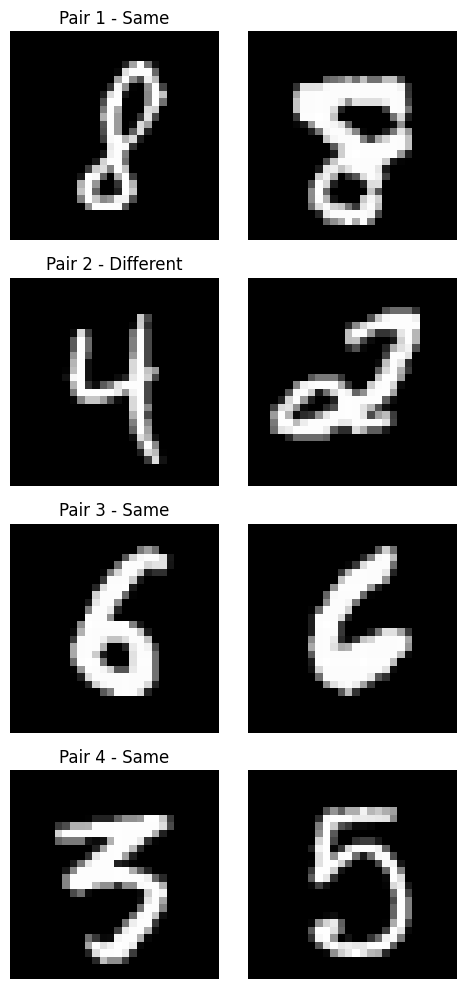

In [6]:

dataiter = iter(train_loader)
img1, img2, label = next(dataiter)

fig, axes = plt.subplots(4, 2, figsize=(5, 10))
for i in range(4):
    axes[i, 0].imshow(img1[i].squeeze(), cmap='gray')
    axes[i, 1].imshow(img2[i].squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Pair {i+1} - {'Same' if label[i]==1 else 'Different'}")
    axes[i, 0].axis('off')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()


---

### **7. Inference (Testing New Pairs)**

You can now compare *any two images*:



In [7]:
model.eval()
img1, img2, label = next(iter(train_loader))
output1, output2 = model(img1.to(device), img2.to(device))
distance = F.pairwise_distance(output1, output2).cpu().detach().numpy()

print("Pairwise distance (lower = more similar):")
print(distance[:10])


Pairwise distance (lower = more similar):
[0.45542634 0.58820635 0.37569177 0.57091933 0.4345667  0.59442
 0.48795345 0.44623834 0.6010004  0.5852639 ]


---

### **🧠 Intuition Recap**

* The network **learns an embedding space** where:

  * Same digits → embeddings are close.
  * Different digits → embeddings are far apart.
* During inference, a **distance threshold** decides similarity.
* This method generalizes to unseen data, perfect for **verification** tasks.

